# A/B Тест
## Проверим гипотезу 1: Перемещение ленты с "платными" элементами вверх списка увеличит конверсию перехода по платным элементам

H0: Перемещение ленты с "платными" элементами вверх списка не изменит конверсию.

H1: Перемещение ленты с "платными" элементами вверх списка увеличит конверсию.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# читаем файл с результатами эксперимента
df = pd.read_csv("AB_Test_revenue_only.csv", delimiter=';')

Проведем предварительный анализ данных

In [2]:
print(df.head(5))

df.info()

   user_id variant_name   revenue
0     9468      control  8.528105
1     9446      control  5.800314
2     8872      control  6.957476
3     3766      control  9.481786
4     1190      control  8.735116
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       10000 non-null  int64  
 1   variant_name  10000 non-null  object 
 2   revenue       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


В данных 3 колонки: user_id, variant_name, revenue. Пропусков нет.
Проверим колонку variant_name.

In [3]:
df['variant_name'].value_counts() 

variant_name
variant    5016
control    4984
Name: count, dtype: int64

Колонка variant_name содержит 2 значения: variant и control, что соответсвует тестовой и контрольной группам.

Проверим пользователей на пересечение между группами.

In [4]:

print(f'всего уникальных пользователей = {df['user_id'].nunique()}')

set_a = set(df[df['variant_name']=='control']['user_id'].unique()) # множество уникальных пользователей контрольной группы
set_b = set(df[df['variant_name']=='variant']['user_id'].unique()) # множество уникальных пользователей тестовой группы
dblusers = set_a & set_b # пересечение множеств
print(f'Количество пользователей попавщих в обе группы {len(dblusers)}')

всего уникальных пользователей = 6324
Количество пользователей попавщих в обе группы 1541


Очистим данные от пользователей попавших в обе группы

In [5]:
# очистка данных 
df_unique = df[~df['user_id'].isin(dblusers)]



Проверим распределение данных на нормальность

In [6]:
# Проверим на нормальность
from statsmodels.stats.diagnostic import lilliefors

s, p = lilliefors(df_unique['revenue'], dist='norm')
print(f'Данные распределены {"нормально" if p > 0.05 else "не нормально"}')

Данные распределены нормально


Посмотрим на данные.

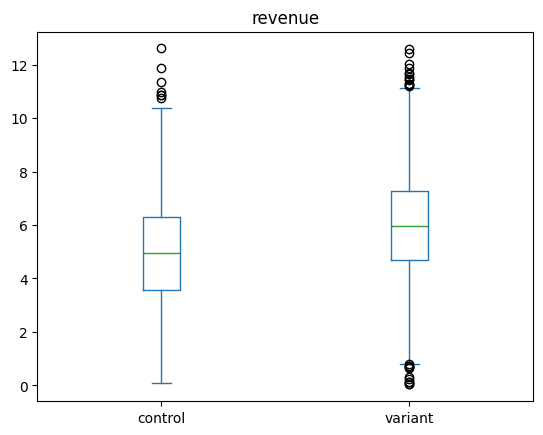

In [7]:
# Посмотрим на графики
import matplotlib.pyplot as plt
# %matplotlib inline

df_unique.plot(kind='box', column='revenue', by='variant_name');

Избавимся от выбросов

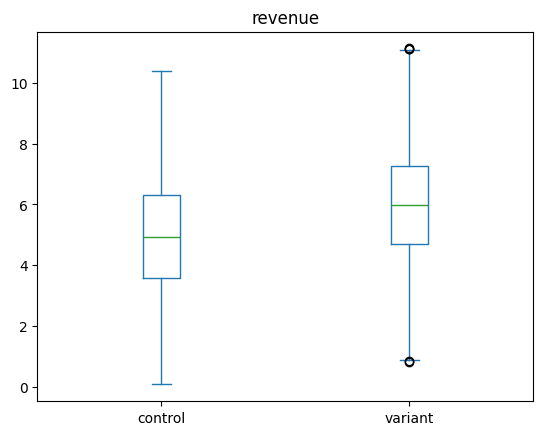

In [9]:
# избавимся от выбросов

q1, q3 = df_unique[df_unique['variant_name']=='variant']['revenue'].quantile([0.25, 0.75])
iqr = q3 - q1
l_b = q1-1.5*iqr
h_b = q3+1.5*iqr
df_v = df_unique[(df_unique['variant_name']=='variant') & (df_unique['revenue'] >= l_b) & (df_unique['revenue'] <= h_b)]

q1, q3 = df_unique[df_unique['variant_name']=='control']['revenue'].quantile([0.25, 0.75])
iqr = q3 - q1
l_b = q1-1.5*iqr
h_b = q3+1.5*iqr
df_c = df_unique[(df_unique['variant_name']=='control') & (df_unique['revenue'] >= l_b) & (df_unique['revenue'] <= h_b)]

df_merged = pd.merge(df_v, df_c, how='outer') 

# посмотрим на график
df_merged.plot(kind='box', column='revenue', by = 'variant_name');


Проведем тест на равенство средних. Данные распределены нормально, можно использовать t-критерий.

In [10]:
# сравним равенство размера выборок 
smpl_eq = abs(200*(len(df_merged[df_merged.variant_name == "control"]) - len(df_merged[df_merged.variant_name == "variant"]))/len(df_merged)) <1

print(f'Можем принять что выборки {"одинакового" if smpl_eq else "разного"} размера')

alpha = 0.05

p_value = stats.ttest_ind(df_merged[df_merged.variant_name == "control"].revenue,
                df_merged[df_merged.variant_name == "variant"].revenue,
                equal_var=smpl_eq).pvalue

if p_value > alpha:
    print('Группы стат значимо не отличаются. Нельзя отвергнуть нулевую гипотезу.')
else:
    print('Отличие в группах статистически значимо. Отвергаем нулевую гипотезу в пользу альтернативной.')


Можем принять что выборки одинакового размера
Отличие в группах статистически значимо. Отвергаем нулевую гипотезу в пользу альтернативной.


Средняя выручка в тестовой группе 5.98, средняя выручка в контрольной группе 4.96, изменение 20.56%


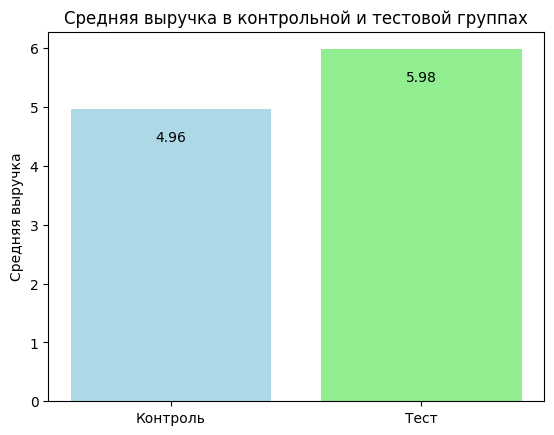

In [17]:
from matplotlib import pyplot as plt

mean_c = round(df_merged[df_merged.variant_name == 'control']['revenue'].mean(),2)
mean_v = round(df_merged[df_merged.variant_name == 'variant']['revenue'].mean(),2)

print(f'Средняя выручка в тестовой группе {mean_v}, средняя выручка в контрольной группе {mean_c}, изменение {100*(mean_v-mean_c)/mean_c:.2f}%')

fig, ax = plt.subplots()
# plt.bar(['control', 'test'], [mean_c, mean_v])
val = ax.bar(['Контроль', 'Тест'], [mean_c, mean_v], color = ['lightblue', 'lightgreen'])
plt.ylabel('Средняя выручка');
# plt.bar_labels([1, 2])
ax.bar_label(val, padding = -25)
ax.set_title('Средняя выручка в контрольной и тестовой группах', fontsize=12)

# plt.subplots.bar_labels([mean_c, mean_v])

plt.show()

Вывод. Тестирование выявило статистически значимое различие средней выручки. Рост средней выручки в группе составил 20.56%